In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tabulate as tb
from matplotlib import font_manager
import os
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#ARQUIVOS NECESSARIOS - 20,21,22,23,24

# 2024
df_atrac2024 = pd.read_csv('/content/drive/MyDrive/2024/2024Atracacao.txt', delimiter=';', encoding='utf-8',  low_memory=False)
df_temp2024 = pd.read_csv('/content/drive/MyDrive/2024/2024TemposAtracacaoParalisacao.txt', delimiter=';', encoding='utf-8',  low_memory=False)

# 2023
df_atrac2023 = pd.read_csv('/content/drive/MyDrive/2023/2023Atracacao.txt', delimiter=';', encoding='utf-8',  low_memory=False)
df_temp2023 = pd.read_csv('/content/drive/MyDrive/2023/2023TemposAtracacaoParalisacao.txt', delimiter=';', encoding='utf-8',  low_memory=False)

# 2022
df_atrac2022 = pd.read_csv('/content/drive/MyDrive/2022/2022Atracacao.txt', delimiter=';', encoding='utf-8',  low_memory=False)
df_temp2022 = pd.read_csv('/content/drive/MyDrive/2022/2022TemposAtracacaoParalisacao.txt', delimiter=';', encoding='utf-8',  low_memory=False)

# 2021
df_atrac2021 = pd.read_csv('/content/drive/MyDrive/2021/2021Atracacao.txt', delimiter=';', encoding='utf-8',  low_memory=False)
df_temp2021 = pd.read_csv('/content/drive/MyDrive/2021/2021TemposAtracacaoParalisacao.txt', delimiter=';', encoding='utf-8',  low_memory=False)

# 2020
df_atrac2020 = pd.read_csv('/content/drive/MyDrive/2020/2020Atracacao.txt', delimiter=';', encoding='utf-8',  low_memory=False)
df_temp2020 = pd.read_csv('/content/drive/MyDrive/2020/2020TemposAtracacaoParalisacao.txt', delimiter=';', encoding='utf-8',  low_memory=False)


In [3]:
#PREPARO DOS DADOS - 20 A 24

def preparar_dados(df_atrac, df_temp, ano):
    df_atrac.columns = df_atrac.columns.str.strip().str.replace('\u200b', '').str.replace('\xa0', '')
    df_temp.columns = df_temp.columns.str.strip().str.replace('\u200b', '').str.replace('\xa0', '')
    colunas = df_temp.columns.tolist()
    if not any(col.strip() == 'IDAtracacao' for col in colunas):
        print(f"Coluna 'IDAtracacao' não encontrada no ano {ano}. Colunas disponíveis:", colunas)
        return pd.DataFrame()

    df_merged = df_temp.merge(
        df_atrac[['IDAtracacao', 'UF', 'Região Geográfica', 'Porto Atracação', 'Município']],
        on='IDAtracacao', how='left'
    )
    df_merged['Ano'] = ano
    return df_merged
df_2024 = preparar_dados(df_atrac2024, df_temp2024, 2024)
df_2023 = preparar_dados(df_atrac2023, df_temp2023, 2023)
df_2022 = preparar_dados(df_atrac2022, df_temp2022, 2022)
df_2021 = preparar_dados(df_atrac2021, df_temp2021, 2021)
df_2020 = preparar_dados(df_atrac2020, df_temp2020, 2020)
df_todos = pd.concat([df for df in [df_2020, df_2021, df_2022, df_2023, df_2024
                                   ] if not df.empty], ignore_index=True)

In [4]:
#TABELA DE MOTIVO E REGIÃO GEOGRÁFICA - ANOS 20,21,22,23,24

graf1 = df_todos.groupby(['Ano', 'Região Geográfica', 'DescricaoTempoDesconto']) \
                .size().reset_index(name='count')
graf1_top = graf1.sort_values(['Ano', 'Região Geográfica', 'count'], ascending=[True, True, False])
graf1_top = graf1_top.groupby(['Ano', 'Região Geográfica']).head(1)
display(graf1_top)

,Ano,Região Geográfica,DescricaoTempoDesconto,count
5,2020,Nordeste,Chuva e/ou outras condições climáticas desfavo...,2111
47,2020,Norte,Problema operacional da embarcação,2872
57,2020,Sudeste,Chuva e/ou outras condições climáticas desfavo...,1704
88,2020,Sul,Mudança de porão,19192
104,2021,Nordeste,Chuva e/ou outras condições climáticas desfavo...,2072
144,2021,Norte,Problema operacional da embarcação,2658
152,2021,Sudeste,Chuva e/ou outras condições climáticas desfavo...,1890
168,2021,Sul,Aguardando transporte rodoviário,20563
198,2022,Nordeste,Chuva e/ou outras condições climáticas desfavo...,2386
236,2022,Norte,Problema operacional da embarcação,3626


In [6]:
colunas = ['IDAtracacao', 'Porto Atracação', 'Data Atracação', 'Data Chegada', 'Data Desatracação',
           'Data Início Operação', 'Data Término Operação', 'Ano', 'Mes', 'Tipo de Operação',
           'Município', 'UF', 'Região Geográfica', 'Região Hidrográfica','Tipo da Autoridade Portuária']

df_atrac20 = pd.read_csv('/content/drive/MyDrive/2020/2020Atracacao.txt', delimiter=';', encoding='utf-8', usecols=colunas, low_memory=False)
df_atrac21 = pd.read_csv('/content/drive/MyDrive/2021/2021Atracacao.txt', delimiter=';', encoding='utf-8', usecols=colunas, low_memory=False)
df_atrac22 = pd.read_csv('/content/drive/MyDrive/2022/2022Atracacao.txt', delimiter=';', encoding='utf-8', usecols=colunas, low_memory=False)
df_atrac23 = pd.read_csv('/content/drive/MyDrive/2023/2023Atracacao.txt', delimiter=';', encoding='utf-8', usecols=colunas, low_memory=False)
df_atrac24 = pd.read_csv('/content/drive/MyDrive/2024/2024Atracacao.txt', delimiter=';', encoding='utf-8', usecols=colunas, low_memory=False)


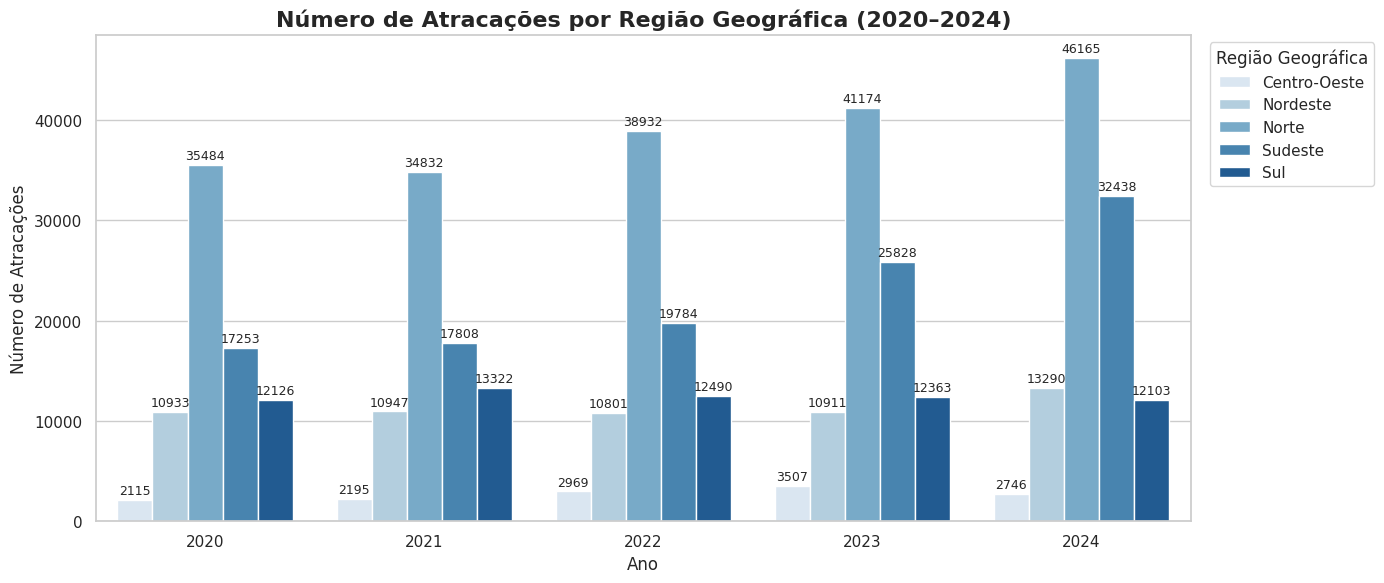

In [7]:
#ATRACACOES POR REGIOES GEOGRAFICAS


df_atrac_total = pd.concat([df_atrac20, df_atrac21, df_atrac22, df_atrac23, df_atrac24], ignore_index=True)

atrac_por_regiao = (
    df_atrac_total
    .groupby(['Ano', 'Região Geográfica'])['Data Atracação']
    .count()
    .reset_index(name='Número de Atracações')
)


ordem_regioes = ['Centro-Oeste', 'Nordeste', 'Norte', 'Sudeste', 'Sul']
atrac_por_regiao['Região Geográfica'] = pd.Categorical(
    atrac_por_regiao['Região Geográfica'],
    categories=ordem_regioes,
    ordered=True
)


sns.set(style="whitegrid")
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=atrac_por_regiao,
    x='Ano',
    y='Número de Atracações',
    hue='Região Geográfica',
    palette='Blues'
)


for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=2, fontsize=9)

plt.title('Número de Atracações por Região Geográfica (2020–2024)', fontsize=16, weight='bold')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Número de Atracações', fontsize=12)
plt.legend(title='Região Geográfica', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


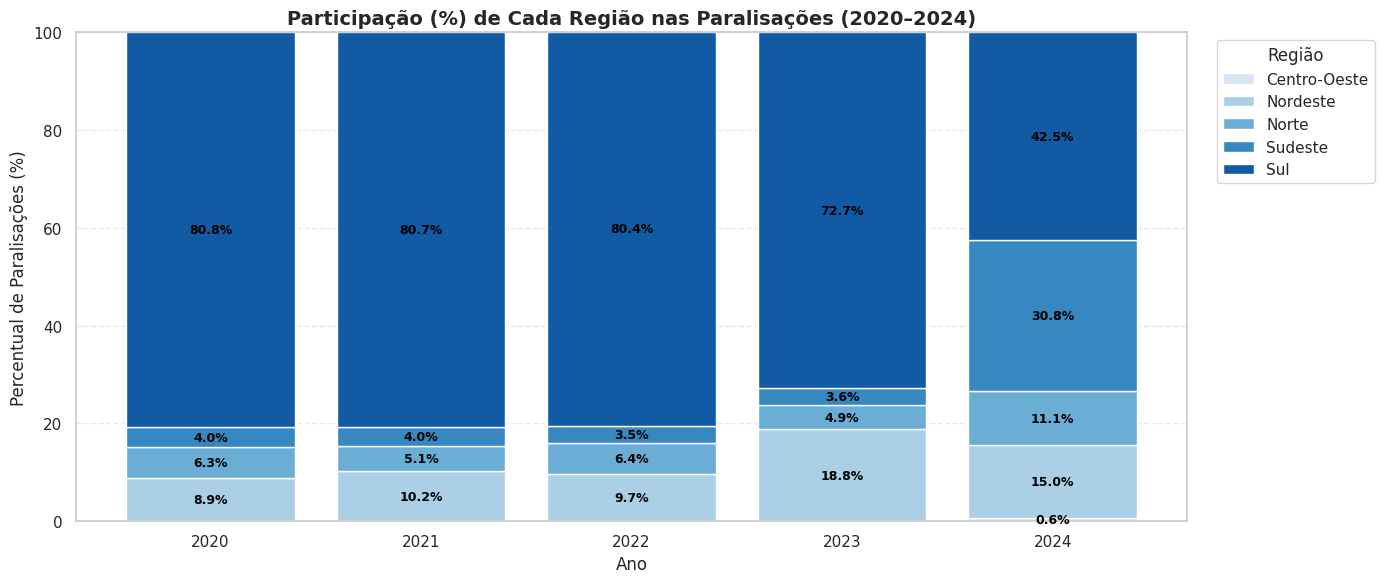

In [8]:
#PARTICIPACAO PERCENTUAL DE CADA REGIAO GEOGRAFICA - 20 A 24

df_part = df_todos.groupby(['Ano', 'Região Geográfica']) \
                  .size().reset_index(name='QtdParalisacoes')
df_part['Perc'] = df_part.groupby('Ano')['QtdParalisacoes'].transform(lambda x: x / x.sum() * 100)
df_pivot = df_part.pivot(index='Ano', columns='Região Geográfica', values='Perc').fillna(0)
fig, ax = plt.subplots(figsize=(14, 6))
bottom = [0] * len(df_pivot)
colors = sns.color_palette("Blues", n_colors=len(df_pivot.columns))

for i, coluna in enumerate(df_pivot.columns):
    valores = df_pivot[coluna].values
    bars = ax.bar(df_pivot.index, valores, bottom=bottom, label=coluna, color=colors[i])
    for idx, bar in enumerate(bars):
        if valores[idx] > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[idx] + valores[idx] / 2,
                f"{valores[idx]:.1f}%",
                ha='center',
                va='center',
                fontsize=9,
                color='black',
                fontweight='bold'
            )
    bottom = [sum(x) for x in zip(bottom, valores)]
ax.set_title("Participação (%) de Cada Região nas Paralisações (2020–2024)", fontsize=14, fontweight='bold')
ax.set_ylabel("Percentual de Paralisações (%)", fontsize=12)
ax.set_xlabel("Ano", fontsize=12)
ax.set_ylim(0, 100)
ax.legend(title='Região', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [11]:
#ATRACACOES NO PORTO DE BELEM - 20 A 24

anos = [2020, 2021, 2022, 2023, 2024]
atracacoes_belem = []

for ano in anos:
    path = f"/content/drive/MyDrive/{ano}/{ano}Atracacao.txt"
    df = pd.read_csv(path, delimiter=";", encoding="utf-8", low_memory=False)

    df_belem = df[df['Porto Atracação'].str.strip().str.lower() == 'belém']

    total = df_belem.shape[0]
    atracacoes_belem.append({"Ano": ano, "Atracações em Belém": total})


df_resultado = pd.DataFrame(atracacoes_belem)
df_resultado.loc["Total"] = ["Total", df_resultado["Atracações em Belém"].sum()]
print(df_resultado.to_string(index=False))




  Ano  Atracações em Belém
 2020                 4843
 2021                 5726
 2022                 5812
 2023                 6224
 2024                 6275
Total                28880


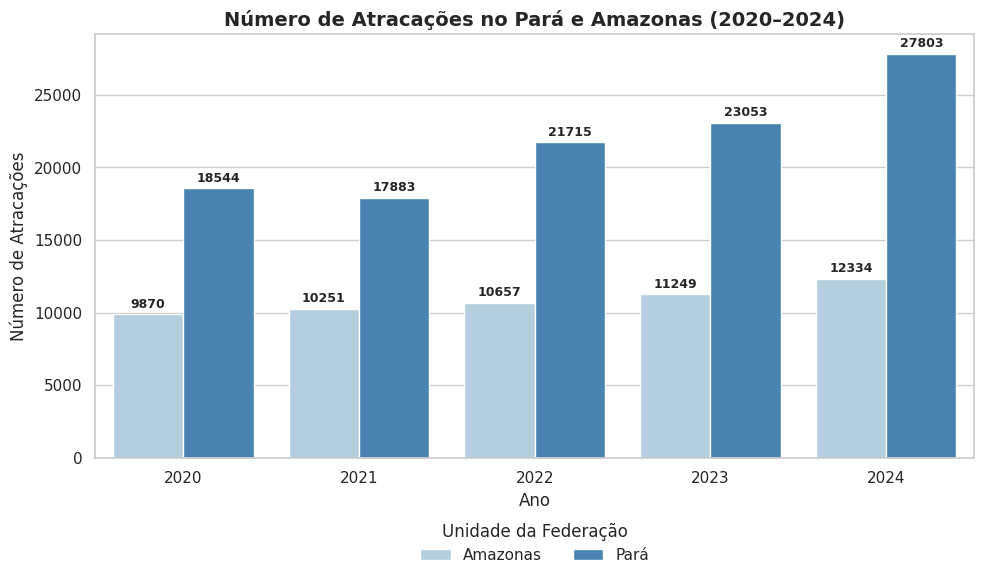

In [13]:
#ATRACACOES NO PARA E AMAZONAS

anos = [2020, 2021, 2022, 2023, 2024]
dfs = []

for ano in anos:
    caminho = f"/content/drive/MyDrive/{ano}/{ano}Atracacao.txt"
    df = pd.read_csv(caminho, sep=';', encoding='utf-8', low_memory=False)
    df['Ano'] = ano
    dfs.append(df)


df_todos = pd.concat(dfs, ignore_index=True)
df_pa_am = df_todos[df_todos['UF'].isin(['Pará', 'Amazonas'])]

atrac_por_uf_ano = df_pa_am.groupby(['Ano', 'UF'])['Data Atracação'].count().reset_index()

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=atrac_por_uf_ano, x='Ano', y='Data Atracação', hue='UF', palette='Blues')


for bars in ax.containers:
    ax.bar_label(bars, fmt='%d', fontsize=9, padding=3, weight='bold')

plt.title("Número de Atracações no Pará e Amazonas (2020–2024)", fontsize=14, weight='bold')
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Número de Atracações", fontsize=12)
plt.legend(
    title="Unidade da Federação",
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()


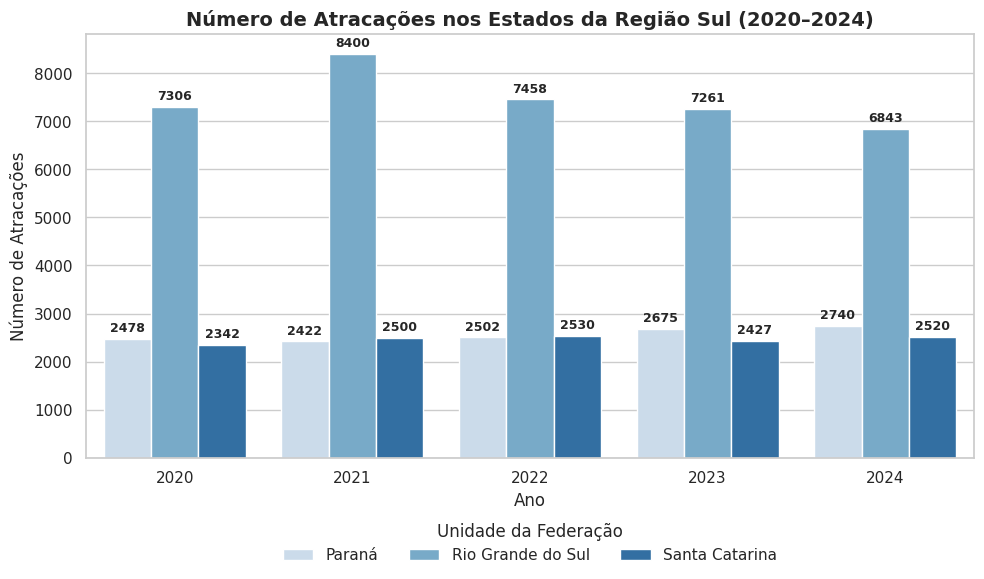

In [14]:
#ATRACACOES NA REGIAO SUL - 20 A 24

anos = [2020, 2021, 2022, 2023, 2024]
dfs = []

for ano in anos:
    caminho = f"/content/drive/MyDrive/{ano}/{ano}Atracacao.txt"
    df = pd.read_csv(caminho, sep=';', encoding='utf-8', low_memory=False)
    df['Ano'] = ano
    dfs.append(df)

df_todos = pd.concat(dfs, ignore_index=True)
ufs_sul = ['Paraná', 'Santa Catarina', 'Rio Grande do Sul']
df_sul = df_todos[df_todos['UF'].isin(ufs_sul)]

atrac_por_uf_ano = df_sul.groupby(['Ano', 'UF'])['Data Atracação'].count().reset_index()
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=atrac_por_uf_ano, x='Ano', y='Data Atracação', hue='UF', palette='Blues')
for bars in ax.containers:
    ax.bar_label(bars, fmt='%d', fontsize=9, padding=3, weight='bold')


plt.title("Número de Atracações nos Estados da Região Sul (2020–2024)", fontsize=14, weight='bold')
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Número de Atracações", fontsize=12)
plt.legend(
    title="Unidade da Federação",
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.show()


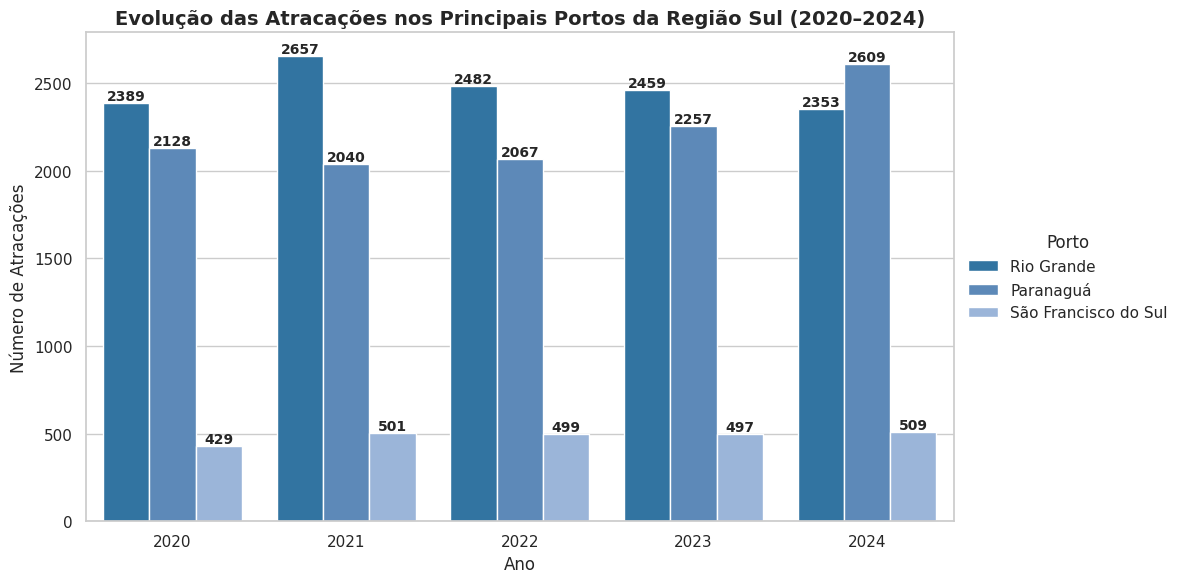

In [15]:
# ATRACACOES NOS PORTOS RIO GRANDE, SAO FRANCISCO DO SUL, PARANAGUA

df_total = pd.DataFrame({
    'Ano': [2020, 2020, 2020, 2021, 2021, 2021, 2022, 2022, 2022, 2023, 2023, 2023, 2024, 2024, 2024],
    'Porto': ['Rio Grande', 'Paranaguá', 'São Francisco do Sul'] * 5,
    'Atracações': [2389, 2128, 429, 2657, 2040, 501, 2482, 2067, 499, 2459, 2257, 497,2353,2609,509]
})


sns.set(style="whitegrid")
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 12})
palette_azul = {
    'Rio Grande': '#1f77b4',
    'Paranaguá': '#4e89c7',
    'São Francisco do Sul': '#91b4e3'
}

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_total, x='Ano', y='Atracações', hue='Porto', palette=palette_azul)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=10, weight='bold')


plt.title('Evolução das Atracações nos Principais Portos da Região Sul (2020–2024)', fontsize=14, weight='bold')
plt.xlabel('Ano')
plt.ylabel('Número de Atracações')
plt.legend(
    title='Porto',
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    frameon=False
)

plt.tight_layout()
plt.savefig('atracacoes_sul_2020_2024.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
#ATRACACOES NO PORTO DE PARANAGUA - 20 A 24

anos = [2020, 2021, 2022, 2023, 2024]
atracacoes_paranagua = []

for ano in anos:
    file_path = f"/content/drive/MyDrive/{ano}/{ano}Atracacao.txt"
    df = pd.read_csv(file_path, delimiter=";", encoding="utf-8", low_memory=False)

    df_parana = df[
        (df['Ano'] == ano) &
        (df['Município'].str.strip().str.lower() == 'paranaguá')
    ]

    total = df_parana.shape[0]
    atracacoes_paranagua.append({"Ano": ano, "Atracações em Paranaguá": total})

df_resultado = pd.DataFrame(atracacoes_paranagua)
df_resultado.loc["Total"] = ["Total", df_resultado["Atracações em Paranaguá"].sum()]


print(df_resultado.to_string(index=False))



  Ano  Atracações em Paranaguá
 2020                     2418
 2021                     2327
 2022                     2405
 2023                     2587
 2024                     2633
Total                    12370


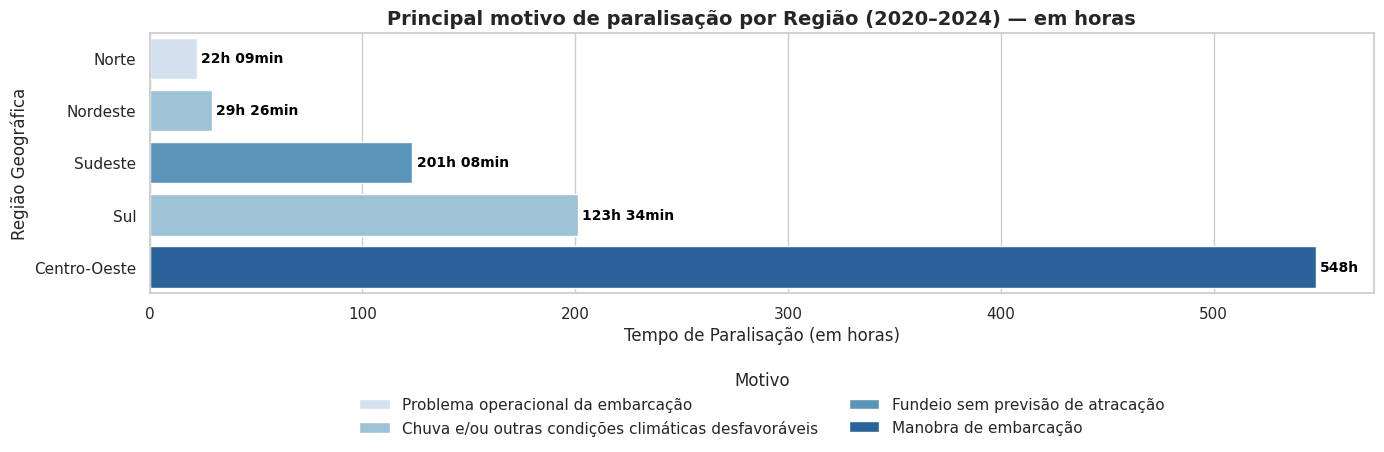

In [21]:
#MOTIVO POR REGIAO GEOGRAFICA - 20 A 24

dados = {
    "Região Geográfica": ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"],
    "DescricaoTempoDesconto": [
        "Problema operacional da embarcação",
        "Chuva e/ou outras condições climáticas desfavoráveis",
        "Fundeio sem previsão de atracação",
        "Chuva e/ou outras condições climáticas desfavoráveis",
        "Manobra de embarcação"
    ],
    "TotalHoras": [22.152, 29.425, 123.568, 201.134, 548]
}

df = pd.DataFrame(dados)
df = df.sort_values("TotalHoras", ascending=True)


def formatar_horas_minutos(valor):
    horas = int(valor)
    minutos = int(round((valor - horas) * 60))
    if minutos == 60:
        horas += 1
        minutos = 0
    if minutos == 0:
        return f"{horas}h"
    return f"{horas}h {minutos:02d}min"


plt.figure(figsize=(14, 5))
barplot = sns.barplot(
    data=df,
    y="Região Geográfica",
    x="TotalHoras",
    hue="DescricaoTempoDesconto",
    palette="Blues"
)


for bar, horas in zip(barplot.patches, df["TotalHoras"]):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    label = formatar_horas_minutos(horas)
    barplot.text(
        width + 2,
        y,
        label,
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='black'
    )


plt.xlabel("Tempo de Paralisação (em horas)", fontsize=12)
plt.ylabel("Região Geográfica", fontsize=12)
plt.title("Principal motivo de paralisação por Região (2020–2024) — em horas", fontsize=14, weight='bold')
plt.legend(
    title="Motivo",
    bbox_to_anchor=(0.5, -0.25),
    loc='upper center',
    ncol=2,
    frameon=False
)
plt.tight_layout()
plt.show()

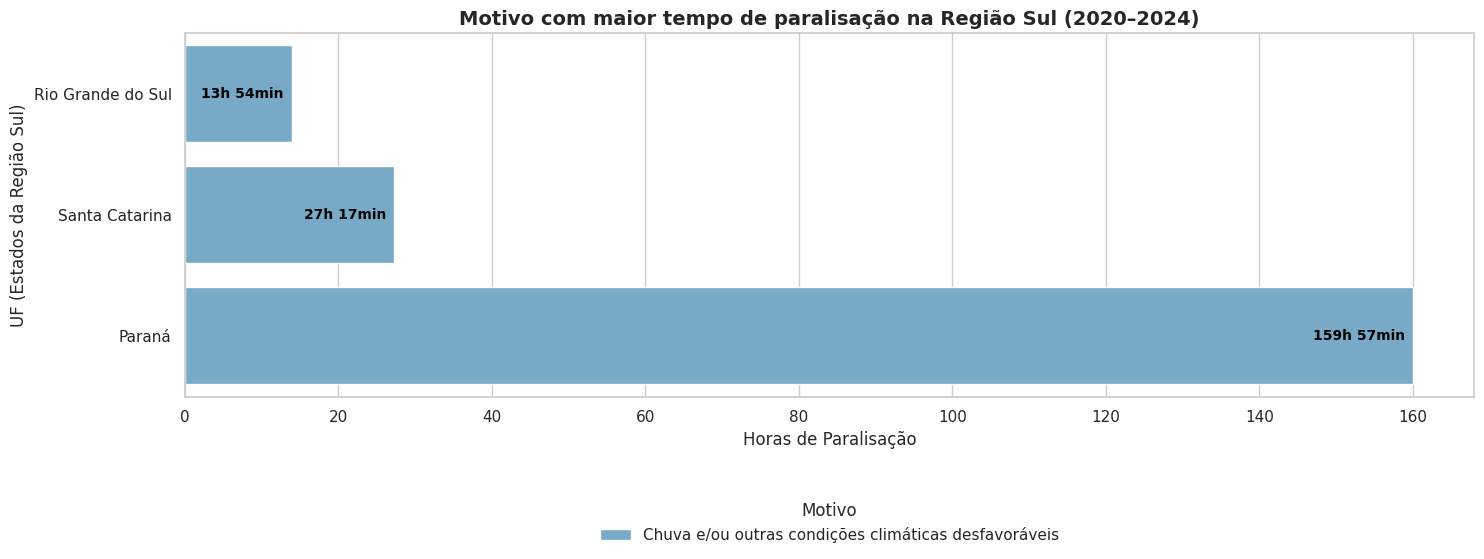

In [22]:
#MOTIVO NA REGIAO SUL - 20 A 24

dados = {
    "UF": ["Rio Grande do Sul", "Santa Catarina", "Paraná"],
    "DescricaoTempoDesconto": [
        "Chuva e/ou outras condições climáticas desfavoráveis"
    ] * 3,
    "Horas": [13.902, 27.276, 159.956]
}
df = pd.DataFrame(dados)

df = df.sort_values("Horas", ascending=True)
def formatar_horas_minutos(valor):
    horas = int(valor)
    minutos = int(round((valor - horas) * 60))
    return f"{horas}h {minutos:02d}min"


plt.figure(figsize=(15, 6))
ax = sns.barplot(
    data=df,
    y="UF",
    x="Horas",
    hue="DescricaoTempoDesconto",
    palette="Blues"
)

for bar, horas in zip(ax.patches, df["Horas"]):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        width - 1,
        y,
        formatar_horas_minutos(horas),
        ha='right',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

plt.xlabel("Horas de Paralisação", fontsize=12)
plt.ylabel("UF (Estados da Região Sul)", fontsize=12)
plt.title("Motivo com maior tempo de paralisação na Região Sul (2020–2024)", fontsize=14, weight='bold')
plt.legend(title="Motivo", bbox_to_anchor=(0.5, -0.25), loc='upper center', ncol=2, frameon=False)
plt.tight_layout()
plt.show()


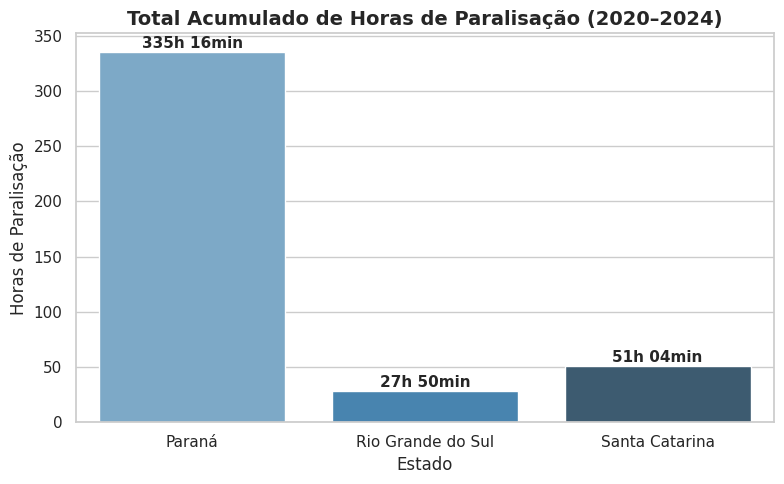

In [23]:
#HORAS ACUMULADAS NOS ESTADOS DO SUL- 20 A 24


valores_corrigidos = {
    'Paraná': 335.263,
    'Rio Grande do Sul': 27.839,
    'Santa Catarina': 51.066
}

def formatar_horas_minutos(valor_decimal):
    horas = int(valor_decimal)
    minutos = int(round((valor_decimal - horas) * 60))
    return f"{horas}h {minutos:02d}min"

df_final_corrigido = pd.DataFrame([
    {'UF': uf, 'Horas': horas, 'Rotulo': formatar_horas_minutos(horas)}
    for uf, horas in valores_corrigidos.items()
])


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
barplot = sns.barplot(data=df_final_corrigido, x='UF', y='Horas', palette='Blues_d')


for i, bar in enumerate(barplot.patches):
    label = df_final_corrigido['Rotulo'].iloc[i]
    height = bar.get_height()
    barplot.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        label,
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Total Acumulado de Horas de Paralisação (2020–2024)", fontsize=14, fontweight='bold')
plt.xlabel("Estado")
plt.ylabel("Horas de Paralisação")
plt.tight_layout()
plt.show()